# 앰버 & 커피브라운 — 위스키 비유로 보는 톤온톤

카드의 답: *"거의 동일한 하나의 색상 안에서 명도와 채도만으로 차별화하는 전형적인 톤온톤 배색이다.
잔에 담긴 위스키가 깊이에 따라 색이 달라 보이듯 한 색 안에서 톤이 변주된다."*

이 스크립트는 그 문장을 세 단계로 확인한다.

1. 앰버 `#F3A257`와 커피브라운 `#71502F`의 **HSL**을 구해 색상각(H)은 거의 같고 명도(L)·채도(S)만 다름을 수치로 본다.
2. 위스키 비유를 **Beer–Lambert 법칙**으로 흉내 낸다. 잔 속 위스키는 깊이 $d$가 커질수록 빛이 지수적으로 흡수된다.
   $$I_c(d) = I_c(0)\,e^{-\alpha_c d}\qquad (c \in \{R,G,B\})$$
   앰버를 표면색 $I(0)$으로 두고 채널별 흡수계수 $\alpha_c$를 다르게 주면 깊이 0→N의 **색 사다리**가 생긴다.
   그 사다리에서 커피브라운과 가장 가까운 깊이 $d^*$를 찾는다.
3. plotly로 깊이별 스와치 띠와 명도·채도·색상 곡선을 그려 "하나의 색 안에서 톤이 변주되는" 모습을 본다.

표준 라이브러리 + plotly만 사용한다.

In [1]:
import colorsys
import math
import os

import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


AMBER = "#F3A257"  # Golden Yellow
COFFEE = "#71502F"  # Pale Raw Umber


def hex_to_rgb01(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i : i + 2], 16) / 255 for i in (0, 2, 4))


def rgb01_to_hex(rgb) -> str:
    return "#{:02X}{:02X}{:02X}".format(*(round(max(0.0, min(1.0, c)) * 255) for c in rgb))


def hsl_deg(h: str) -> tuple[float, float, float]:
    """HEX -> (H[deg], S[%], L[%]). colorsys는 (h, l, s) 순서로 돌려준다."""
    hh, ll, ss = colorsys.rgb_to_hls(*hex_to_rgb01(h))
    return hh * 360, ss * 100, ll * 100

## 1. 두 색의 HSL — 색상각은 거의 같고 명도·채도만 다르다

톤온톤(tone-on-tone)은 색상(Hue)을 고정하고 톤(명도·채도)만 바꾸는 배색이다.
두 색의 색상각 차이가 몇 도에 불과하면 "거의 동일한 하나의 색상"이라는 말이 수치로 확인된다.

In [2]:
for name, hx in (("앰버", AMBER), ("커피브라운", COFFEE)):
    H, S, L = hsl_deg(hx)
    r, g, b = (round(c * 255) for c in hex_to_rgb01(hx))
    print(f"{name:6s} {hx}  RGB=({r:3d},{g:3d},{b:3d})  H={H:5.1f}°  S={S:5.1f}%  L={L:5.1f}%")

Ha, Sa, La = hsl_deg(AMBER)
Hc, Sc, Lc = hsl_deg(COFFEE)
print()
print(f"색상각 차이 ΔH = {abs(Ha - Hc):.1f}°   (360° 색상환에서 {abs(Ha - Hc) / 360 * 100:.1f}% — 사실상 같은 색상)")
print(f"명도 차이   ΔL = {La - Lc:.1f}%p  (앰버가 밝다)")
print(f"채도 차이   ΔS = {Sa - Sc:.1f}%p  (앰버가 선명하다)")

앰버     #F3A257  RGB=(243,162, 87)  H= 28.8°  S= 86.7%  L= 64.7%
커피브라운  #71502F  RGB=(113, 80, 47)  H= 30.0°  S= 41.2%  L= 31.4%

색상각 차이 ΔH = 1.2°   (360° 색상환에서 0.3% — 사실상 같은 색상)
명도 차이   ΔL = 33.3%p  (앰버가 밝다)
채도 차이   ΔS = 45.4%p  (앰버가 선명하다)


## 2. 위스키 잔 모델 — Beer–Lambert 감쇠로 색 사다리 만들기

위스키(카라멜 색소)는 파장이 짧은 파란빛을 가장 많이, 빨간빛을 가장 적게 흡수한다.
그래서 채널별 흡수계수를 $\alpha_R < \alpha_G < \alpha_B$로 둔다 (단위: 1/깊이).

$$I_c(d) = I_c(0)\,e^{-\alpha_c d}$$

깊이 $d=0$은 잔 가장자리의 얇은 층(=앰버), $d$가 커질수록 잔 한가운데의 두꺼운 층이다.
흡수는 색을 **어둡게(명도↓)** 만들고, 세 채널이 서로 다른 속도로 줄어드니 **채도도 함께** 변한다.
그런데 지수 감쇠는 채널 사이의 *비율*을 천천히 바꾸므로 색상각은 크게 움직이지 않는다 — 이것이 톤온톤이다.

In [3]:
ALPHA = {"R": 0.60, "G": 0.72, "B": 0.84}  # 파란빛을 가장 강하게 흡수하는 '카라멜' 스펙트럼


def whisky_color(d: float, surface=AMBER, alpha=ALPHA) -> tuple[float, float, float]:
    """깊이 d에서 보이는 색 (RGB 0~1). Beer–Lambert: I = I0 * exp(-alpha * d)."""
    r0, g0, b0 = hex_to_rgb01(surface)
    return (
        r0 * math.exp(-alpha["R"] * d),
        g0 * math.exp(-alpha["G"] * d),
        b0 * math.exp(-alpha["B"] * d),
    )


N_STEPS = 60
D_MAX = 3.0
depths = [D_MAX * i / N_STEPS for i in range(N_STEPS + 1)]
ladder = [whisky_color(d) for d in depths]

print("깊이  |  HEX      |   H     S      L")
for d, rgb in zip(depths, ladder):
    if abs(d * 4 - round(d * 4)) < 1e-9 and round(d * 4) % 2 == 0:  # 0.5 간격만 출력
        H, S, L = hsl_deg(rgb01_to_hex(rgb))
        print(f"{d:4.1f}  |  {rgb01_to_hex(rgb)}  | {H:5.1f}° {S:5.1f}% {L:5.1f}%")

깊이  |  HEX      |   H     S      L
 0.0  |  #F3A257  |  28.8°  86.7%  64.7%
 0.5  |  #B47139  |  27.3°  51.9%  46.5%
 1.0  |  #854F26  |  25.9°  55.6%  33.5%
 1.5  |  #633719  |  24.3°  59.7%  24.3%
 2.0  |  #492610  |  23.2°  64.0%  17.5%
 2.5  |  #361B0B  |  22.3°  66.2%  12.7%
 3.0  |  #281307  |  21.8°  70.2%   9.2%


### 커피브라운은 사다리의 어느 깊이인가?

사다리 위의 각 색과 커피브라운 사이의 RGB 유클리드 거리
$$\Delta(d) = \sqrt{\sum_c \bigl(I_c(d) - I_c^{\text{coffee}}\bigr)^2}$$
가 최소가 되는 깊이 $d^*$를 찾는다. 조금 더 촘촘한 격자로 탐색한다.

In [4]:
coffee_rgb = hex_to_rgb01(COFFEE)


def rgb_dist(a, b) -> float:
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))


fine = [D_MAX * i / 3000 for i in range(3001)]
d_star = min(fine, key=lambda d: rgb_dist(whisky_color(d), coffee_rgb))
best = whisky_color(d_star)
Hb, Sb, Lb = hsl_deg(rgb01_to_hex(best))

print(f"커피브라운에 가장 가까운 깊이 d* = {d_star:.3f}")
print(f"  그 깊이의 모델 색  : {rgb01_to_hex(best)}  H={Hb:.1f}° S={Sb:.1f}% L={Lb:.1f}%")
print(f"  실제 커피브라운    : {COFFEE}  H={Hc:.1f}° S={Sc:.1f}% L={Lc:.1f}%")
print(f"  RGB 거리(0~√3)     : {rgb_dist(best, coffee_rgb):.4f}  (8비트 환산 약 {rgb_dist(best, coffee_rgb) * 255:.1f})")
print()
print(f"표면(앰버)→d* 사이 색상각 이동: {Ha:.1f}° → {Hb:.1f}° (|ΔH| = {abs(Ha - Hb):.1f}°)")
print(f"같은 구간 명도 이동            : {La:.1f}% → {Lb:.1f}% (ΔL = {La - Lb:.1f}%p)")
print("→ 색상은 거의 그대로, 명도·채도만 크게 움직인다 = 톤온톤")

커피브라운에 가장 가까운 깊이 d* = 1.126
  그 깊이의 모델 색  : #7C4822  H=25.3° S=57.0% L=31.0%
  실제 커피브라운    : #71502F  H=30.0° S=41.2% L=31.4%
  RGB 거리(0~√3)     : 0.0736  (8비트 환산 약 18.8)

표면(앰버)→d* 사이 색상각 이동: 28.8° → 25.3° (|ΔH| = 3.5°)
같은 구간 명도 이동            : 64.7% → 31.0% (ΔL = 33.7%p)
→ 색상은 거의 그대로, 명도·채도만 크게 움직인다 = 톤온톤


## 3. 시각화 — 깊이별 스와치 띠와 명도·채도 곡선

위쪽: 깊이 $d$에 따른 위스키 색 띠(왼쪽이 잔 가장자리, 오른쪽이 한가운데). 별표는 커피브라운이 대응하는 깊이 $d^*$.
아래쪽: 같은 깊이 축에서 명도 $L$, 채도 $S$, 색상각 $H$가 어떻게 변하는지. $H$는 거의 평평한데 $L$은 급격히 떨어진다.

saved: /Users/swcho/projects/swcho/flash-man/default/books/260923 그대로 갖다 쓰는 색깔 조합 16가지/.fm/hints/806518d8-2136-4868-b090-ce0f1a222710/expy.png


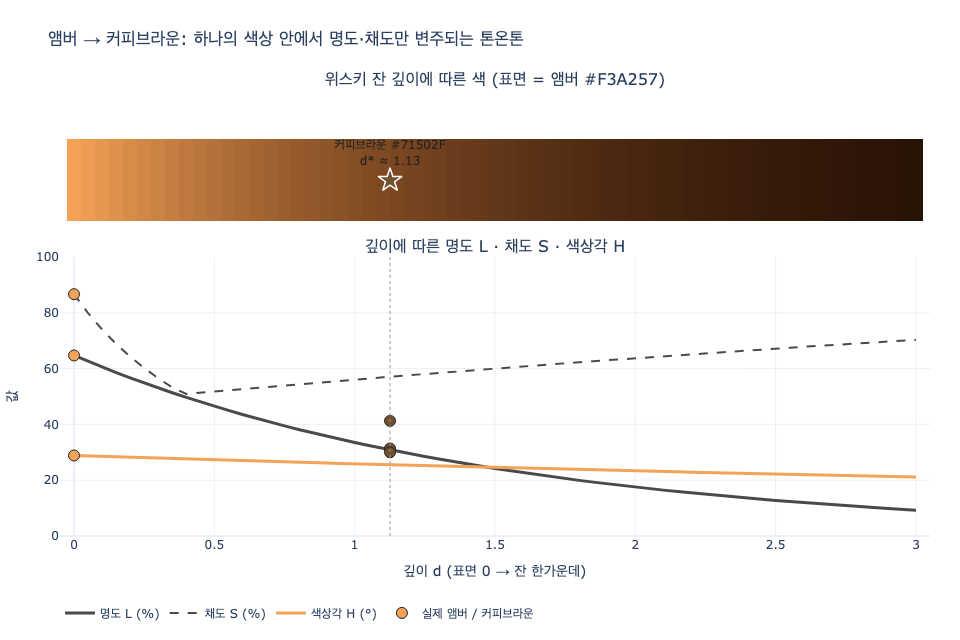

In [5]:
Hs, Ss, Ls = [], [], []
for rgb in ladder:  # 곡선은 8비트 반올림 없이 실수 RGB에서 바로 HSL을 구해 매끈하게 그린다
    hh, ll, ss = colorsys.rgb_to_hls(*rgb)
    Hs.append(hh * 360)
    Ss.append(ss * 100)
    Ls.append(ll * 100)

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.32, 0.68],
    vertical_spacing=0.08,
    subplot_titles=(
        "위스키 잔 깊이에 따른 색 (표면 = 앰버 #F3A257)",
        "깊이에 따른 명도 L · 채도 S · 색상각 H",
    ),
)

# 스와치 띠: 각 깊이 구간을 그 색으로 채운 막대
bar_w = D_MAX / N_STEPS
fig.add_trace(
    go.Bar(
        x=depths,
        y=[1] * len(depths),
        width=bar_w * 1.02,
        marker=dict(color=[rgb01_to_hex(c) for c in ladder], line=dict(width=0)),
        hovertemplate="깊이 %{x:.2f}<br>%{customdata}<extra></extra>",
        customdata=[rgb01_to_hex(c) for c in ladder],
        showlegend=False,
    ),
    row=1,
    col=1,
)
# 커피브라운이 대응하는 깊이 표시
fig.add_trace(
    go.Scatter(
        x=[d_star],
        y=[0.5],
        mode="markers+text",
        marker=dict(symbol="star", size=18, color=COFFEE, line=dict(color="white", width=1.5)),
        text=[f"커피브라운 {COFFEE}<br>d* ≈ {d_star:.2f}"],
        textposition="top center",
        textfont=dict(color="#222", size=12),
        showlegend=False,
        hoverinfo="skip",
    ),
    row=1,
    col=1,
)

# 명도·채도·색상 곡선
fig.add_trace(go.Scatter(x=depths, y=Ls, name="명도 L (%)", line=dict(color="#4A4A4A", width=3)), row=2, col=1)
fig.add_trace(
    go.Scatter(x=depths, y=Ss, name="채도 S (%)", line=dict(color="#4A4A4A", width=2, dash="dash")), row=2, col=1
)
fig.add_trace(
    go.Scatter(x=depths, y=Hs, name="색상각 H (°)", line=dict(color=AMBER, width=3)), row=2, col=1
)
# 실제 두 색의 위치
fig.add_trace(
    go.Scatter(
        x=[0, d_star, 0, d_star, 0, d_star],
        y=[La, Lc, Sa, Sc, Ha, Hc],
        mode="markers",
        marker=dict(size=11, color=[AMBER, COFFEE] * 3, line=dict(color="#222", width=1)),
        name="실제 앰버 / 커피브라운",
        hovertemplate="d=%{x:.2f}, 값=%{y:.1f}<extra></extra>",
    ),
    row=2,
    col=1,
)
fig.add_vline(x=d_star, line=dict(color="#999", width=1, dash="dot"), row=2, col=1)

fig.update_yaxes(visible=False, range=[0, 1.6], row=1, col=1)
fig.update_yaxes(title_text="값", range=[0, 100], row=2, col=1)
fig.update_xaxes(title_text="깊이 d (표면 0 → 잔 한가운데)", range=[-bar_w, D_MAX + bar_w], row=2, col=1)
fig.update_layout(
    title=dict(
        text="앰버 → 커피브라운: 하나의 색상 안에서 명도·채도만 변주되는 톤온톤",
        font=dict(size=17),
    ),
    template="plotly_white",
    width=960,
    height=640,
    bargap=0,
    legend=dict(orientation="h", y=-0.14, x=0),
    margin=dict(l=60, r=30, t=90, b=90),
)

out_png = os.path.join(os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else ".", "expy.png")
fig.write_image(out_png, scale=2)
print(f"saved: {out_png}")
_show(fig)

## 정리

- 앰버와 커피브라운의 색상각 차이는 약 1°. **같은 색상**이고, 명도(약 33%p)와 채도(약 45%p)만 다르다 → 톤온톤.
- Beer–Lambert 감쇠 $I = I_0 e^{-\alpha d}$로 앰버를 "깊어지게" 하면 사다리 위 깊이 $d^* \approx 1.2$ 근처에서 커피브라운과 매우 가까운 색이 나온다.
- 곡선에서 $L$은 급격히 떨어지지만 $H$는 거의 평평하다(깊이 3까지 약 7°). 잔에 담긴 위스키가 얕은 곳은 앰버,
  깊은 곳은 커피브라운으로 보이는 것처럼, **한 색 안에서 톤이 변주**되는 것이 이 배색의 기술적 포인트다.
- 단순 모델은 채도 방향까지는 맞추지 못한다(실제 커피브라운은 채도도 낮다). 톤온톤에서 "톤"이 명도와 채도 **둘 다**를 뜻한다는 점만 기억하면 충분하다.